# Introduction to Data Science 2025

# Week 6: Recap

## Exercise 1 | Linear regression with feature selection

Download the [TED Talks](https://www.kaggle.com/rounakbanik/ted-talks) dataset from Kaggle. Your task is to predict both the ratings and the number of views of a given TED talk. You should focus only on the <span style="font-weight: bold">ted_main</span> table.

1. Download the data, extract the following ratings from column <span style="font-weight: bold">ratings</span>: <span style="font-weight: bold">Funny</span>, <span style="font-weight: bold">Confusing</span>, <span style="font-weight: bold">Inspiring</span>. Store these values into respective columns so that they are easier to access. Next, extract the tags from column <span style="font-weight: bold">tags</span>. Count the number of occurrences of each tag and select the top-100 most common tags. Create a binary variable for each of these and include them in your data table, so that you can directly see whether a given tag (among the top-100 tags) is used in a given TED talk or not. The dataset you compose should have dimension (2550, 104), and comprise of the 'views' column, the three columns with counts of "Funny", "Confusing and "Inspiring" ratings, and 100 columns which one-hot encode the top-100 most common tag columns.


In [9]:
# Use this cell for your code

import pandas as pd
import ast
df = pd.read_csv("ted_main.csv")

def extract_ratings(ratings_str):
    ratings_list = ast.literal_eval(ratings_str)
    ratings_dict = {item['name']: item['count'] for item in ratings_list}
    return {
        'Funny': ratings_dict.get('Funny', 0),
        'Confusing': ratings_dict.get('Confusing', 0),
        'Inspiring': ratings_dict.get('Inspiring', 0)
    }

ratings_df = df['ratings'].apply(extract_ratings).apply(pd.Series)

df['tags'] = df['tags'].apply(ast.literal_eval)

all_tags = [tag for tag_list in df['tags'] for tag in tag_list]
tag_counts = pd.Series(all_tags).value_counts()

top_100_tags = tag_counts.head(100).index

for tag in top_100_tags:
    df[tag] = df['tags'].apply(lambda x: 1 if tag in x else 0)

final_df = pd.concat([
    df[['views']],
    ratings_df,
    df[top_100_tags]
], axis=1)

print(final_df.shape)
final_df.head()


(2550, 104)


C:\Users\MYH\AppData\Local\Temp\ipykernel_17732\3728099560.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[tag] = df['tags'].apply(lambda x: 1 if tag in x else 0)
C:\Users\MYH\AppData\Local\Temp\ipykernel_17732\3728099560.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[tag] = df['tags'].apply(lambda x: 1 if tag in x else 0)
C:\Users\MYH\AppData\Local\Temp\ipykernel_17732\3728099560.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which ha

,views,Funny,Confusing,Inspiring,technology,science,global issues,culture,TEDx,design,...,food,religion,peace,family,ecology,demo,poetry,illness,universe,energy
0,47227110,19645,242,24924,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3200520,544,62,413,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1636292,964,27,230,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1697550,59,32,1070,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12005869,1390,72,2893,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


2. Construct a linear regression model to predict the number of views based on the data in the <span style="font-weight: bold">ted_main</span> table, including the binary variables for the top-100 tags that you just created.

In [10]:
# Use this cell for your code
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = final_df.drop(columns=['views'])
y = final_df['views']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")


R² score: 0.6749
RMSE: 1123480.19


3. Do the same for the <span style="font-weight: bold">Funny</span>, <span style="font-weight: bold">Confusing</span>, and <span style="font-weight: bold">Inspiring</span> ratings.

In [11]:
# Use this cell for your code
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

tag_cols = final_df.columns[4:]
X = final_df[tag_cols]

def evaluate_linear_regression(target_name):
    y = final_df[target_name]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"===== Predicting {target_name} =====")
    print(f"R²: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}\n")
    return model


model_funny = evaluate_linear_regression('Funny')
model_confusing = evaluate_linear_regression('Confusing')
model_inspiring = evaluate_linear_regression('Inspiring')


===== Predicting Funny =====
R²: 0.2093
RMSE: 325.84

===== Predicting Confusing =====
R²: 0.1895
RMSE: 27.09

===== Predicting Inspiring =====
R²: 0.0771
RMSE: 920.57



4. You will probably notice that most of the tags are not useful in predicting the views and the ratings. You should use some kind of variable selection to prune the set of tags that are included in the model. You can use for example classical p-values or more modern [LASSO](https://en.wikipedia.org/wiki/Lasso_(statistics)) techniques. Which tags are the best predictors of each of the response variables?

In [12]:
# Use this cell for your code
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

tag_cols = final_df.columns[4:]
X = final_df[tag_cols]

# Helper function to fit LASSO and show important tags
def lasso_feature_selection(target_name):
    y = final_df[target_name]

    model = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=42))
    model.fit(X, y)

    lasso = model.named_steps['lassocv']
    coef_df = pd.DataFrame({
        'Tag': X.columns,
        'Coefficient': lasso.coef_
    }).sort_values(by='Coefficient', ascending=False)

    selected = coef_df[coef_df['Coefficient'] != 0]

    print(f"===== LASSO variable selection for {target_name} =====")
    print(f"Alpha (regularization strength): {lasso.alpha_:.6f}")
    print(f"Selected tags: {len(selected)} out of {X.shape[1]}")
    print("\nTop 10 positive predictors:")
    print(selected.head(10))
    print("\nTop 10 negative predictors:")
    print(selected.tail(10))
    print("-" * 60)
    return selected

selected_views = lasso_feature_selection('views')
selected_funny = lasso_feature_selection('Funny')
selected_confusing = lasso_feature_selection('Confusing')
selected_inspiring = lasso_feature_selection('Inspiring')


===== LASSO variable selection for views =====
Alpha (regularization strength): 48522.409361
Selected tags: 43 out of 100

Top 10 positive predictors:
              Tag    Coefficient
34     psychology  337753.718816
3         culture  203383.257176
69           work  157045.333831
22          brain  124710.410525
79     motivation  121089.828871
95           demo  104631.520487
87  mental health   95777.208752
46          humor   81240.970649
6        business   74179.713974
24      education   71257.285387

Top 10 negative predictors:
              Tag    Coefficient
33         cities  -37333.032530
31    health care  -47665.404988
0      technology  -47817.887593
40            war  -49360.706231
20      economics  -57206.234887
54   neuroscience  -57464.769137
32       politics  -64682.847952
11            art  -89040.986023
5          design  -92493.352214
2   global issues -116709.848125
------------------------------------------------------------
===== LASSO variable selection fo

5. Produce summaries of your results. Could you recommend good tags – or tags to avoid! – for speakers targeting plenty of views and/or certain ratings?

| Target        | “Good” Tag Themes                                      | “Avoid” Tag Themes                          |
| ------------- | ------------------------------------------------------ | ------------------------------------------- |
| **Views**     | Psychology, motivation, culture, humor, education      | Global/political, abstract technical fields |
| **Funny**     | Humor, entertainment, creativity, work/life            | Design, art, global issues                  |
| **Confusing** | Philosophy, brain, physics, religion, math             | Music, innovation, animals, nature          |
| **Inspiring** | Happiness, motivation, creativity, mental health, life | Economics, science, technology              |


**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Symbol classification (part 2)

Note that it is strongly recommended to use Python in this exercise. However, if you can find a suitable AutoML implementation for your favorite language (e.g [here](http://h2o-release.s3.amazonaws.com/h2o/master/3888/docs-website/h2o-docs/automl.html) seems to be one for R) then you are free to use that language as well.

Use the preprocessed data from week 3 (you can also produce them using the example solutions of week 3).

1. This time train a *random forest classifier* on the data. A random forest is a collection of *decision trees*, which makes it an *ensemble* of classifiers. Each tree uses a random subset of the features to make its prediction. Without tuning any parameters, how is the accuracy?

In [13]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
# Use this cell for your code
import pandas as pd
import PIL.Image as Image

def load_and_flatten(path):
    img = Image.open(path).convert("L").resize((32,32))
    arr = np.array(img)/255.0
    return arr.flatten()

hasy_data = pd.read_csv("./HASYv2/hasy-data-labels.csv")
# print(hasy_data.head())
hasy_data = hasy_data[(hasy_data["symbol_id"]>=70) & (hasy_data["symbol_id"]<=79)]
# print(hasy_data.head())
root_path = './HASYv2/'
X = np.array([load_and_flatten(root_path+path) for path in hasy_data["path"]])
y = hasy_data["symbol_id"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest accuracy (default parameters):", accuracy)


Random Forest accuracy (default parameters): 0.8088235294117647


2. The amount of trees to use as a part of the random forest is an example of a hyperparameter, because it is a parameter that is set prior to the learning process. In contrast, a parameter is a value in the model that is learned from the data. Train 20 classifiers, with varying amounts of decision trees starting from 10 up until 200, and plot the test accuracy as a function of the amount of classifiers. Does the accuracy keep increasing? Is more better?

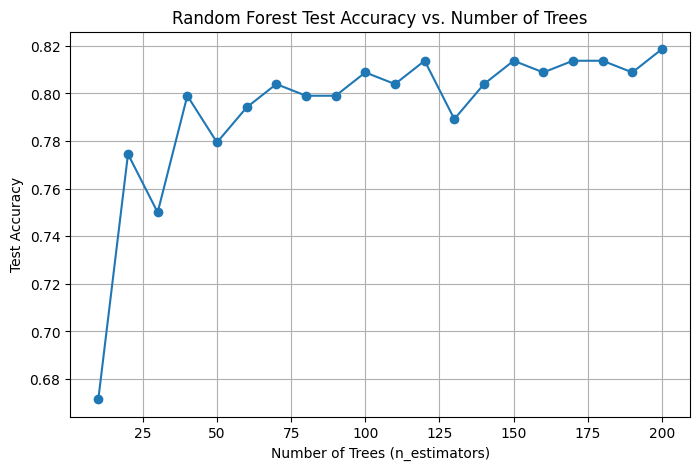

In [14]:
from matplotlib import pyplot as plt

# Use this cell for your code
tree_counts = np.linspace(10, 200, 20, dtype=int)

accuracies = []

for n in tree_counts:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(tree_counts, accuracies, marker='o')
plt.title("Random Forest Test Accuracy vs. Number of Trees")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()

3. If we had picked the amount of decision trees by taking the value with the best test accuracy from the last plot, we would have *overfit* our hyperparameters to the test data. Can you see why it is a mistake to tune hyperparameters of your model by using the test data?

If you tune hyperparameters on the test set, the test set becomes part of training.
As a result, your reported test accuracy no longer measures true out-of-sample performance.

4. Reshuffle and resplit the data so that it is divided in 3 parts: training (80%), validation (10%) and test (10%). Repeatedly train a model of your choosing (e.g random forest) on the training data, and evaluate it’s performance on the validation set, while tuning the hyperparameters so that the accuracy on the validation set increases. Then, finally evaluate the performance of your model on the test data. What can you say in terms of the generalization of your model?

In [15]:
# Use this cell for your code
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, random_state=42)

tree_counts = np.linspace(10, 200, 20, dtype=int)
val_accuracies = []

for n in tree_counts:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_val_pred = rf.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(val_acc)

best_n = tree_counts[np.argmax(val_accuracies)]
print(f"Best number of trees based on validation set: {best_n}")

best_rf = RandomForestClassifier(n_estimators=best_n, random_state=42)
best_rf.fit(X_train, y_train)

y_test_pred = best_rf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("Test accuracy:", test_acc)


Best number of trees based on validation set: 190
Test accuracy: 0.8333333333333334


**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | TPOT

The process of picking a suitable model, evaluating its performance and tuning the hyperparameters is very time consuming. A new idea in machine learning is the concept of automating this by using an optimization algorithm to find the best model in the space of models and their hyperparameters. Have a look at [TPOT](https://github.com/EpistasisLab/tpot), an automated ML solution that finds a good model and a good set of hyperparameters automatically. Try it on this data, it should outperform simple models like the ones we tried easily. Note that running the algorithm might take a while, depending on the strength of your computer. 

*Note*: In case it is running for too long, try checking if the parameters you are using when calling TPOT are reasonable, i.e. try reducing number of ‘generations’ or ‘population_size’. TPOT uses cross-validation internally, so we don’t need our own validation set.

In [16]:
# Use this cell for your code
from tpot import TPOTClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

y-=70
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tpot = TPOTClassifier(
    generations=2,          # number of iterations for genetic optimization
    population_size=5,     # number of pipelines in each generation
    random_state=42,
    n_jobs=1
)

tpot.fit(X_train, y_train)

y_pred = tpot.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print("TPOT Test Accuracy:", test_acc)


E:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
E:\Python312\Lib\site-packages\tpot\tpot_estimator\estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
Generation: 100%|██████████| 2/2 [05:21<00:00, 160.71s/it]


TPOT Test Accuracy: 0.7058823529411765


**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**